Import bibiotek

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import re
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import normalize, MinMaxScaler

Data prep do modelu

In [2]:
# Load data
data = pd.read_csv('../Database/Dataset_4f_time_only/clustering_results_4c_4f.csv')

In [3]:
# Create vocabulary dictionary
vocab_top = ['-p', '+p', '-l', '+l', 'd']
vocab_seq = ['1', '2', '3', '4']
vocab = {}
token_id = 0

for t in vocab_top:
    for s in vocab_seq:
        fused = f'{t}_{s}'
        vocab[fused] = token_id
        token_id += 1


def tokenize_sequence(token, vocab):
    tokenized = []
    for i in range(3):  # Since sequences are exactly length 3
        fused_key = token[i]
        tokenized.append(vocab[fused_key])
    return tokenized


# Tokenize data
data['splited_top'] = data['top'].apply(lambda text: re.findall(r'[+-][pl]|d', str(text)))
data['splited_seq'] = data['seq'].apply(lambda text: re.findall(r'1|2|3|4', str(text)))

data['tokens'] = data.apply(lambda row: [f'{top}_{seq}' for top, seq in zip(row['splited_top'], row['splited_seq'])],
                            axis=1)
data['tokenased'] = data.apply(lambda row: tokenize_sequence(row['tokens'], vocab), axis=1)

#scaler = MinMaxScaler(feature_range=(0, 1))
#scaled_avg_time=scaler.fit_transform(data['sredni_czas'].to_numpy().reshape(-1, 1))
#data['min_max_avg_time'] = scaled_avg_time
df_filtered=data.copy()

# 2. Calculate the baseline math
Y_MEAN = df_filtered['sredni_czas'].mean()
Y_STD = df_filtered['sredni_czas'].std()

# 3. Create a normalized column for PyTorch to learn
df_filtered['time_normalized'] = (df_filtered['sredni_czas'] - Y_MEAN) / Y_STD
data['time_normal']=df_filtered['time_normalized']
data=data.dropna()

Data manipulation to test

In [ ]:
#data=pd.read_csv('Dataset_4f_time_only/clustering_results_4c_4f.csv')
df_zero = data[data['sredni_czas']==0]
df_non_zero = data[data['sredni_czas']!=0]
df_zero_sample=df_zero.sample(frac=0.05, random_state=42)
#data = pd.concat([df_non_zero, df_zero_sample])
data = df_non_zero
data=data.reset_index(drop=True)
print(data)
print(data['sredni_czas'].value_counts(0))

Model

In [15]:
#data['log_avg_time']=np.log(data['sredni_czas'].replace(0, np.nan))
#data['log_avg_time']=data['log_avg_time'].fillna(0)
X = data['tokenased']
Y = data['sredni_czas']
#Y = data['log_avg_time']
#Y=data['time_normal']


# Split data
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.176, random_state=42)

# X tensors: Convert pandas series of lists -> list of lists -> LongTensor (required for nn.Embedding)
X_train_tensor = torch.tensor(X_train.tolist(), dtype=torch.long)
X_val_tensor = torch.tensor(X_val.tolist(), dtype=torch.long)
X_test_tensor = torch.tensor(X_test.tolist(), dtype=torch.long)

# Y tensors: Extract values first, then convert to FloatTensor
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)
Y_val_tensor = torch.tensor(Y_val.values, dtype=torch.float32).view(-1, 1)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

# Datasets and Loaders
batch_size = 16
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Model architecture
class GQuadPredictor(nn.Module):
    def __init__(self, vocab_size=20, embedding_dim=6, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)
        flattened_size = 3 * embedding_dim
        self.fc1 = nn.Linear(flattened_size, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(p=0.2)
        self.fc4 = nn.Linear(32, 8)
        self.fc5 = nn.Linear(8, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        x = embedded.view(embedded.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.dropout(x)
        x = self.fc4(x)
        stability_prediction = self.fc5(x)
        return stability_prediction


# Instantiate model, loss, and optimizer
model = GQuadPredictor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.000075, weight_decay=1.2e-5)
epochs = 20000

best_val_loss=float('inf')
how_many=50
counter_dd=0

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        prediction = model(batch_X)
        loss = criterion(prediction, batch_Y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Fixed variable name
    avg_train_loss = total_loss / len(train_loader)

    # Evaluate every 10 epochs
    model.eval()
    with torch.no_grad():
        # Fixed variables to use the validation tensors
        val_predictions = model(X_val_tensor)
        val_loss = criterion(val_predictions, Y_val_tensor).item()
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter_dd = 0
    else:
        counter_dd += 1

    if epoch %10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
    if counter_dd >= how_many:
        print("Early Stopping")
        best_val_loss = np.sqrt(best_val_loss)
        #print(f'Średni błąd Validacji: {best_val_loss:.4f}')
        break

learned_vectors = model.embedding.weight.detach().numpy()


Epoch 000 | Train Loss: 158812387636.6028 | Val Loss: 156315746304.0000
Epoch 010 | Train Loss: 158640023580.0548 | Val Loss: 156252028928.0000
Epoch 020 | Train Loss: 156927008375.2329 | Val Loss: 154493911040.0000
Epoch 030 | Train Loss: 146830673555.2877 | Val Loss: 143931473920.0000
Epoch 040 | Train Loss: 119193735981.5890 | Val Loss: 116457709568.0000
Epoch 050 | Train Loss: 86973219461.2603 | Val Loss: 83933339648.0000
Epoch 060 | Train Loss: 74000041843.7260 | Val Loss: 68490002432.0000
Epoch 070 | Train Loss: 69622010865.9726 | Val Loss: 63874932736.0000
Epoch 080 | Train Loss: 66798933426.8493 | Val Loss: 61451751424.0000
Epoch 090 | Train Loss: 65619970749.3699 | Val Loss: 59627978752.0000
Epoch 100 | Train Loss: 64212601926.1370 | Val Loss: 57886375936.0000
Epoch 110 | Train Loss: 62274794622.2466 | Val Loss: 56376635392.0000
Epoch 120 | Train Loss: 60610123102.6849 | Val Loss: 54967316480.0000
Epoch 130 | Train Loss: 59145148023.2329 | Val Loss: 53648715776.0000
Epoch 140 

In [ ]:
print(data)

In [ ]:
print(vocab)

In [ ]:

# 2. Get your token names (labels) in the exact order of their IDs
# This ensures that vector 0 gets labeled '-p_1', vector 1 gets labeled '+p_1', etc.
labels = [None] * len(vocab)
for token, token_id in vocab.items():
    labels[token_id] = token

# 3. Use PCA to "squish" the 8-dimensional arrays down into 2-dimensional (X, Y) points
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(learned_vectors)

# 4. Draw the map!
plt.figure(figsize=(10, 8))

# Plot the dots (X coordinates are column 0, Y coordinates are column 1)
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='skyblue', edgecolors='black', s=100)

# Stick the correct text label right next to every single dot
for i, label in enumerate(labels):
    plt.annotate(
        label,
        (vectors_2d[i, 0], vectors_2d[i, 1]), # X and Y coordinates of the dot
        xytext=(5, 5),                        # Offset the text slightly so it doesn't cover the dot
        textcoords='offset points',
        fontsize=12,
        fontweight='bold'
    )

# Make it look nice
plt.title("Map of G-Quadruplex Tokens (8D flattened to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot on your screen
plt.show()

--- FINAL EXAM RESULTS ---
On average, the model is off by: 41303870824.70 time units
R-squared Score (Accuracy proxy): 0.59


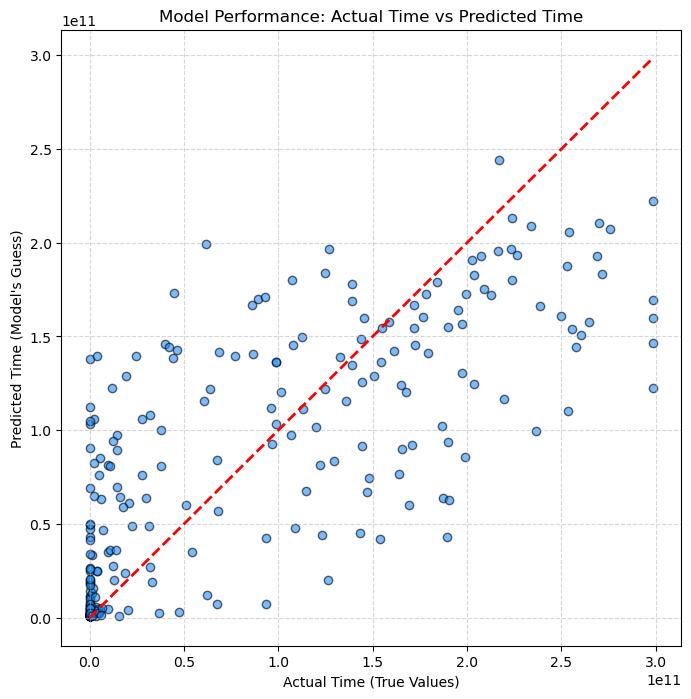

In [16]:
# 1. Put the model into evaluation mode (turns off training features)
model.eval()

# 2. Make predictions on the completely unseen TEST data
with torch.no_grad():
    test_predictions = model(X_test_tensor)

# 3. Convert PyTorch Tensors back to normal Numpy arrays
# (Matplotlib and Sklearn prefer normal arrays)
actuals = Y_test_tensor.numpy()
preds = test_predictions.numpy()

preds = (preds * Y_STD) + Y_MEAN
actuals = (actuals * Y_STD) + Y_MEAN

# if using np.log() data
#actuals = 10**actuals
#preds = 10**preds

# 4. Calculate "Human-Readable" Scores
# MAE (Mean Absolute Error): On average, how many units of time is the prediction wrong by?
mae = mean_absolute_error(actuals, preds)

# R2 Score: A percentage of how well the model fits the data (1.0 is perfect, 0.0 is terrible)
r2 = r2_score(actuals, preds)

print("--- FINAL EXAM RESULTS ---")
print(f"On average, the model is off by: {mae:.2f} time units")
print(f"R-squared Score (Accuracy proxy): {r2:.2f}")

# 5. Draw the "Actual vs. Predicted" Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.6, color='dodgerblue', edgecolors='k')

# Draw a red diagonal line. If the model is perfect, all blue dots will sit exactly on this red line.
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Make the plot look nice
plt.title("Model Performance: Actual Time vs Predicted Time")
plt.xlabel("Actual Time (True Values)")
plt.ylabel("Predicted Time (Model's Guess)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [34]:
torch.save(model.state_dict(), '../modele - wytrenowane/model_toptime_good_nomal.pth')

In [ ]:
model_fast_save=model.state_dict()

In [ ]:
print(model.state_dict())

Fast tokkenizasion


In [ ]:
data = pd.read_csv('../Database/Dataset_4f_time_only/clustering_results_4c_4f.csv')

# Create vocabulary dictionary
vocab_top = ['-p', '+p', '-l', '+l', 'd']
vocab_seq = ['1', '2', '3', '4']
vocab = {}
token_id = 0

for t in vocab_top:
    for s in vocab_seq:
        fused = f'{t}_{s}'
        vocab[fused] = token_id
        token_id += 1


def tokenize_sequence(token, vocab):
    tokenized = []
    for i in range(3):  # Since sequences are exactly length 3
        fused_key = token[i]
        tokenized.append(vocab[fused_key])
    return tokenized


# Tokenize data
data['splited_top'] = data['top'].apply(lambda text: re.findall(r'[+-][pl]|d', str(text)))
data['splited_seq'] = data['seq'].apply(lambda text: re.findall(r'1|2|3|4', str(text)))

data['tokens'] = data.apply(lambda row: [f'{top}_{seq}' for top, seq in zip(row['splited_top'], row['splited_seq'])],
                            axis=1)
data['tokenased'] = data.apply(lambda row: tokenize_sequence(row['tokens'], vocab), axis=1)

X = data['tokenased']
Y = data['sredni_czas']

Test Code for scaling because i dunno

In [ ]:
data_scale=data['sredni_czas'].to_numpy()
norm_Data=normalize([data_scale])
data['normalised_avg_time']=norm_Data[0]
#print(norm_Data)
scaler=MinMaxScaler(feature_range=(0,1))
#print([data_scale])
data_scale=data_scale.reshape(-1,1)
scaled_data=scaler.fit_transform(data_scale)
#print(scaled_data)
data['min_max_avg_time']=scaled_data

In [ ]:
data.to_csv('data_test.csv', index=False)

In [ ]:
vecory=pd.DataFrame(learned_vectors.T, columns=vocab)
print(vecory)

In [ ]:
vecory.to_csv('Vectory.csv', index=False)